# CVAI: Compression

## Aufgabe 1

Wählen Sie aus dem u. g. Binärbild eine Zeile aus. Implementieren Sie eine Lauflängencodierung und codieren Sie die Zeile. Implementieren Sie die Decodierung und überprüfen Sie, ob die wieder decodierte Zeile mit der Originalzeile übereinstimmt.

In [3]:
import numpy as np
import matplotlib.pyplot as pl
import cv2 as cv

path = '/exchange/cvai/images/'

In [4]:
Image0 = cv.imread (path + 'lenna-bw-bin.pbm')
print (Image0.shape)

(512, 512, 3)


In [5]:
Image1 = cv.cvtColor (Image0, cv.COLOR_BGR2GRAY)
print (Image1.shape, np.min (Image1), np.max (Image1))

(512, 512) 0 255


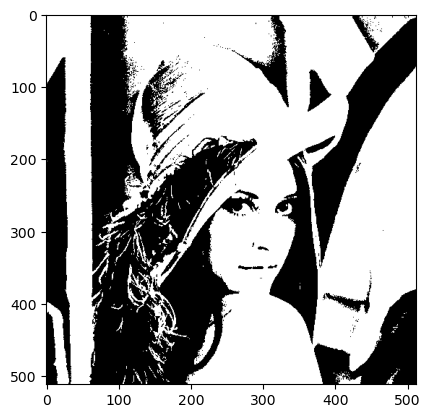

In [6]:
pl.imshow (Image1, cmap = 'gray')

In [7]:

def run_length_encoding(Image1):
    # Run Length Encoding Assumption first pixel is black
    run_length_array = []
    #print(Image1)
    #print(Image1[0][500])
    counter = 0
    last_color = 'black'
    for y in range(Image1.shape[0]):
        for x in range(Image1.shape[1]):
            if Image1[y][x] == 0 and last_color == 'black':
                #black and lc = black
                counter+=1
            elif Image1[y][x] == 0 and last_color == 'white':
                #black and lc = white
                run_length_array.append(counter)
                counter = 1
                last_color = 'black'
            elif Image1[y][x] == 255 and last_color == 'black':
                #white and lc = black
                run_length_array.append(counter)
                counter = 1
                last_color = 'white'
            else:
                #white and lc = white
                counter+=1
    run_length_array.append(counter)
    return run_length_array

def invert_last_color(lc):
    if lc == 0:
        return 255
    elif lc == 255:
        return 0
    else:
        return -1

def decode_run_length_encoding_grey_picture(run_length_encoding, image, last_color=0):
    #make empty picture
    image = np.zeros((image.shape[0], image.shape[1], 1), dtype=np.uint8)
    last_color = last_color
    last_x_position = 0
    last_y_position = 0
    
    for encoding_length in run_length_encoding:
        if last_y_position > image.shape[0]:
            break
        elif encoding_length + last_x_position > image.shape[1]:
            #fill row and begin new row 
            overspill = encoding_length + last_x_position - image.shape[1]
            image[last_y_position, last_x_position:image.shape[1]] = last_color
            last_y_position +=1
            
            if last_y_position > image.shape[0]:
                break
            else: 
                image[last_y_position, 0:overspill] = last_color
                last_color = invert_last_color(last_color)
                last_x_position=overspill
        else:
            image[last_y_position, last_x_position:last_x_position+encoding_length] = last_color
            last_color = invert_last_color(last_color)
            last_x_position+=encoding_length
    return image
        

    
        
            

Setzen Sie alle Zeilen des Bildes zu einer einzigen Zeile zusammen und wiederholen Sie obige Rechnung. Stellen Sie das wieder decodierte Bild dar.

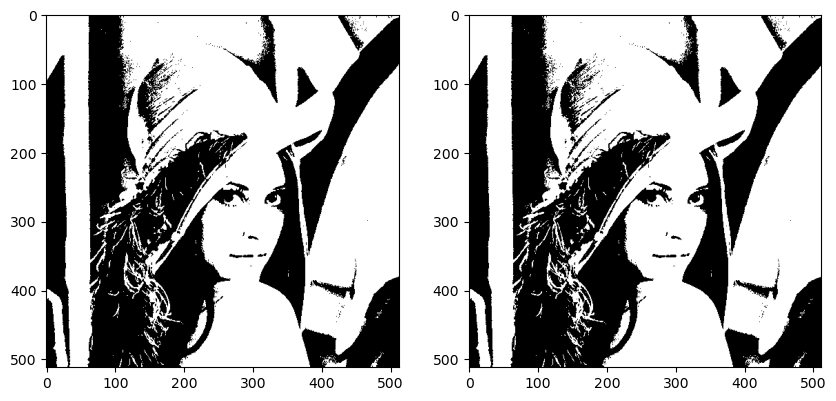

In [8]:
fig, axes = pl.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns
axes[0].imshow(Image1, cmap='gray')  # Use 'gray' for grayscale images
run_length_array = run_length_encoding(Image1)
decoded_image = decode_run_length_encoding_grey_picture(run_length_array, Image1)
axes[1].imshow(decoded_image, cmap='gray')



Ändern Sie das codierte Bild so ab, dass es beim Decodieren negativ dargestellt wird.

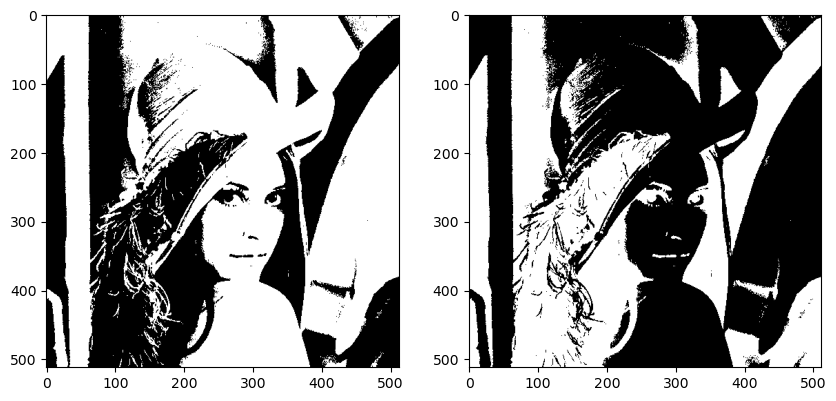

In [9]:
fig, axes = pl.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns
axes[0].imshow(Image1, cmap='gray')  # Use 'gray' for grayscale images
run_length_array = run_length_encoding(Image1)

#call function with 255 as black 
decoded_image = decode_run_length_encoding_grey_picture(run_length_array, Image1, 255)
axes[1].imshow(decoded_image, cmap='gray')



## Aufgabe 2

Implementieren Sie die LZW-Komprimierung und -Dekomprimierung in Python. Verwenden Sie die Beispiele aus der Vorlesung, um Ihre Implementationen zu überprüfen.

In [10]:
# genau Implementation nochmals anschauen
def lz78_compress(s):
    dictionary = {}
    code = []
    w = ""  # current phrase
    dict_pos = 1

    def get_index(sub):
        # return the dictionary index of sub if it exists, else 0
        for k, v in dictionary.items():
            if v == sub:
                return k
        return 0

    for c in s:
        if w + c in dictionary.values():
            # keep extending the phrase
            w += c
        else:
            # output code: (index(w), c)
            prefix_index = get_index(w)  # 0 if not found
            code.append((prefix_index, c))
            # add w+c to dictionary
            dictionary[dict_pos] = w + c
            dict_pos += 1
            # reset w
            w = ""

    # if anything remains in w, output it with an empty next char
    if w != "":
        prefix_index = get_index(w)
        code.append((prefix_index, ""))

    return code, dictionary


In [11]:
string = "abbcbcababcaabcaab"
code_array, dictionary = lz78_compress(string)
print(code_array)
print(dictionary)

[(0, 'a'), (0, 'b'), (2, 'c'), (3, 'a'), (2, 'a'), (4, 'a'), (6, 'b')]
{1: 'a', 2: 'b', 3: 'bc', 4: 'bca', 5: 'ba', 6: 'bcaa', 7: 'bcaab'}


In [12]:
## LZW Compression and Decompression

In [13]:
def get_index(sub, dictionary):
        # return the dictionary index of sub if it exists, else 0
        for k, v in dictionary.items():
            if v == sub:
                return k
        return 0
    
def init_ascii_dict():
    # Create a dictionary where each key is an integer (0-255)
    # and each value is the corresponding ASCII character.
    ascii_dict = {i: chr(i) for i in range(256)}
    return ascii_dict


def lzw_compression(string):
    ''' returns a sequence of indexes'''
    lw = string[0]
    ascii_dictionary = init_ascii_dict()
    output = []
    current_dict_index = len(ascii_dictionary)
    
    for current_index in range(1, len(string)):
        cc = string[current_index]
        #check if lw + cc is in dict
        if get_index(lw+cc, ascii_dictionary) != 0:
            #is in dict make lw longer
            lw = lw + cc
        else:
            output.append(get_index(lw, ascii_dictionary))
            ascii_dictionary[current_dict_index] = lw + cc
            lw = cc
            current_dict_index += 1
    return output
            
    
        
    

In [14]:
output = lzw_compression("rabarbarbarbara")
print(output)

[114, 97, 98, 97, 114, 258, 260, 259, 261]


In [15]:
def lzw_decompression(encoded_array):
    ascii_dictionary = init_ascii_dict()
    
    lw = ascii_dictionary[encoded_array[0]]
    decoded_string = ""
    decoded_string += lw
    next_index = 256

    for i in range(1, len(encoded_array)):
        code = encoded_array[i]
        if code in ascii_dictionary.keys():
            entry = ascii_dictionary[code]
        else:
            entry = lw + lw[0]
            
        decoded_string += entry
        ascii_dictionary[next_index] = lw + entry[0]
        next_index+=1
        lw = entry
            
    
    return decoded_string

In [16]:
output = lzw_compression("rabarbarbarbara")
print(lzw_decompression(output))

rabarbarbarbar
